# 05 · Деформация ткани: преднагрузка и установившееся сокращение

Три конфигурации механической сетки:

* **исходная** — опорная сетка (координаты `m_coords` снимка);
* **после преднагрузки** — растяжение вдоль волокна до λ_f ≈ 1.2575 с зажатыми краями;
  берётся самый ранний снимок, когда активная сила ещё не развилась;
* **установившийся удар** — снимки последнего удара; деформация сокращения отсчитывается
  **от преднагрузки**: смещение `u(t) − u_pre`, растяжение волокна `λ_f / λ_f,pre − 1`
  (синий — укорочение, красный — удлинение, серый — как при преднагрузке).

Сокращение при зажатых краях — единицы процентов, на рисунке в натуральную величину оно
почти не видно. Поэтому в разделах 3–6 смещения от преднагрузки увеличены в `AMPLIFY` раз
(это указано в заголовках); цвет всегда показывает истинное растяжение.

Нужны снимки (`output.snapshot_times_ms`) в первом и в последнем ударе — в ночных сериях
они есть. DOLFINx не нужен.

In [1]:
# Общая настройка: пакет cardiac_em и помощники ноутбуков доступны из любой папки проекта
import sys
from pathlib import Path

for _p in (Path.cwd(), *Path.cwd().parents):
    if (_p / "notebooks" / "nbtools.py").exists():
        sys.path.insert(0, str(_p / "notebooks"))
        break
from nbtools import ROOT, RUNS, run_stream, style  # noqa: E402

print("корень проекта:", ROOT)

корень проекта: /home/user020/cardio2d


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize, TwoSlopeNorm
from cardiac_em.analysis import open_run, open_sweep

style.apply()

RUN_DIR = RUNS / "night_1hz" / "run_000"     # 15 мин ишемии; run_002 — контроль
SWEEP_DIR = RUNS / "night_1hz"               # для сравнения стадий (раздел 7)
AMPLIFY = 5.0      # во сколько раз увеличить смещения ОТ ПРЕДНАГРУЗКИ на рисунках 3–6
MESH_LINES = 20    # сколько линий сетки рисовать по каждой оси
SAVE = True

run = open_run(RUN_DIR)
FIG_DIR = run.dir / "figures"
FIG_DIR.mkdir(exist_ok=True)
M = run.meshes["mechanical"]
STIM = sorted(run.config["stimulus"]["times_ms"])
T_END = run.manifest["schedule"]["t_end_ms"]
LAMBDA_PRE = run.config["preload"]["stretch"]


def save(fig, name):
    if SAVE:
        fig.savefig(FIG_DIR / f"{name}.png", dpi=160, bbox_inches="tight")


def geometry(sn):
    """Опорные координаты узлов и перемещения, карты (ny+1, nx+1)."""
    return (sn.grid("m_coords", 0), sn.grid("m_coords", 1),
            sn.grid("m_u", 0), sn.grid("m_u", 1))


def region_on_nodes(sn):
    """Доля ячеек региона вокруг узла — контур 0.5 даёт границу региона."""
    r = np.pad((sn.grid("m_region") > 0).astype(float), 1, mode="edge")
    return 0.25 * (r[:-1, :-1] + r[1:, :-1] + r[:-1, 1:] + r[1:, 1:])


def draw(ax, X, Y, C, cmap, norm, region=None, title=""):
    """Ячейки цветом C на сетке узлов (X, Y), редкие линии сетки, граница региона."""
    pc = ax.pcolormesh(X, Y, C, cmap=cmap, norm=norm, shading="flat")
    step = max(1, (X.shape[1] - 1) // MESH_LINES)
    segs = ([np.column_stack([X[i], Y[i]]) for i in range(0, X.shape[0], step)] +
            [np.column_stack([X[:, j], Y[:, j]]) for j in range(0, X.shape[1], step)])
    ax.add_collection(LineCollection(segs, colors=style.ink, linewidths=0.3, alpha=0.45))
    if region is not None and region.max() > 0.5:
        ax.contour(X, Y, region, [0.5], colors=style.ink, linewidths=1.2, linestyles="--")
    ax.set_aspect("equal")
    ax.grid(False)
    ax.set_title(title)
    ax.set_xlabel("x, мм")
    ax.set_ylabel("y, мм")
    return pc


def reference_outline(ax):
    lx, ly = M["lx_mm"], M["ly_mm"]
    ax.plot([0, lx, lx, 0, 0], [0, 0, ly, ly, 0], color=style.muted, lw=1, ls=":",
            label="исходная граница")


print(f"прогон {run.dir.relative_to(ROOT)}: механическая сетка {M['nx']}×{M['ny']}, "
      f"стимулы {STIM[0]:g} … {STIM[-1]:g} мс (всего {len(STIM)}), t_end = {T_END:g} мс")

прогон runs/night_1hz/run_000: механическая сетка 40×40, стимулы 1 … 9001 мс (всего 10), t_end = 10000 мс


## 1. Опорные кадры

* **преднагрузка** — самый ранний снимок; проверяется, что активная сила в нём мала;
* **последний удар** — снимки после последнего стимула;
* **пик** — снимок последнего удара с наибольшим средним действующим напряжением.

In [3]:
snaps = list(run.snapshots())
if not snaps:
    raise RuntimeError("в прогоне нет снимков — задайте output.snapshot_times_ms")

pre = snaps[0]
last_stim = max(t for t in STIM if t < T_END)
beat = [sn for sn in snaps if sn.t_ms >= last_stim]
if not beat:
    raise RuntimeError(f"нет снимков после последнего стимула ({last_stim:g} мс)")
peak = max(beat, key=lambda s: s["m_t_act"].mean())

X0, Y0, ux_pre, uy_pre = geometry(pre)
lam_pre = pre.grid("m_lambda_f")
reg_cells = pre.grid("m_region")

print(f"преднагрузка: снимок t = {pre.t_ms:g} мс, λ_f = {lam_pre.min():.4f}–{lam_pre.max():.4f} "
      f"(задано {LAMBDA_PRE:g}), T_act ≤ {pre['m_t_act'].max():.2f} кПа")
print(f"последний удар: стимул {last_stim:g} мс, снимков {len(beat)}: "
      + ", ".join(f"{s.t_ms:g}" for s in beat))
print(f"пик: t = {peak.t_ms:g} мс (через {peak.t_ms - last_stim:g} мс после стимула), "
      f"T_act средн. {peak['m_t_act'].mean():.1f} кПа")
if pre["m_t_act"].max() > 0.05 * peak["m_t_act"].max():
    print("  [!] в кадре преднагрузки активная сила уже > 5 % пиковой — добавьте снимок "
          "раньше (например, на 1–2 мс) в output.snapshot_times_ms")


def strain(sn):
    """Растяжение волокна относительно преднагрузки, %."""
    return 100.0 * (sn.grid("m_lambda_f") / lam_pre - 1.0)


def deformed(sn, amplify=1.0):
    """Узлы: преднагрузка + amplify · (смещение от преднагрузки)."""
    _, _, ux, uy = geometry(sn)
    return (X0 + ux_pre + amplify * (ux - ux_pre),
            Y0 + uy_pre + amplify * (uy - uy_pre))

преднагрузка: снимок t = 5 мс, λ_f = 1.2575–1.2575 (задано 1.2575), T_act ≤ 0.00 кПа
последний удар: стимул 9001 мс, снимков 12: 9005, 9010, 9020, 9050, 9100, 9150, 9200, 9250, 9300, 9400, 9600, 9900
пик: t = 9250 мс (через 249 мс после стимула), T_act средн. 51.8 кПа


## 2. Исходная сетка → преднагрузка → пик сокращения (натуральная величина)

Слева и в центре цвет — абсолютное λ_f (одна шкала), справа — растяжение относительно
преднагрузки. Пунктир — граница исходной области, штриховая линия — граница региона.

размер области: исходный 8×8 мм → преднагрузка 10.060×6.266 мм → пик 10.060×6.266 мм


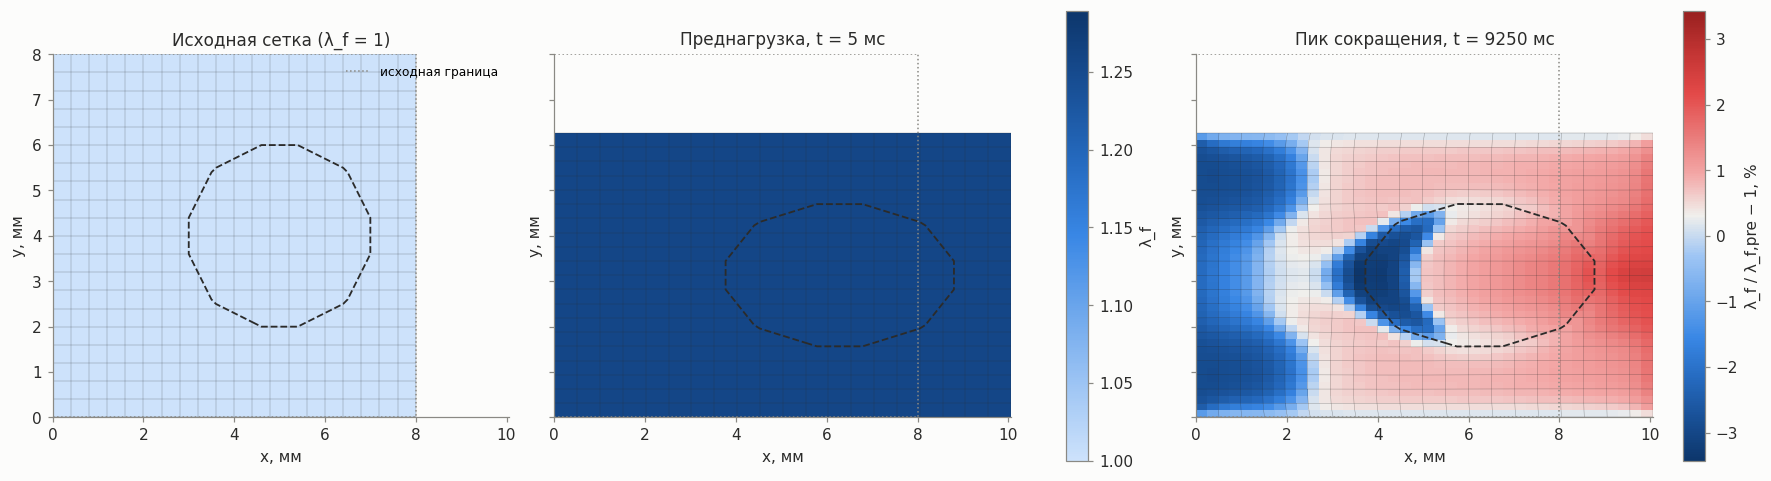

In [4]:
region_n = region_on_nodes(pre)
Xp, Yp = deformed(pre)
Xk, Yk = deformed(peak)
lam_norm = Normalize(1.0, max(lam_pre.max(), peak.grid("m_lambda_f").max()))
s_peak = strain(peak)
span = max(np.abs(s_peak).max(), 1e-6)
s_norm = TwoSlopeNorm(0.0, -span, span)

fig, axs = plt.subplots(1, 3, figsize=(16, 5.2), constrained_layout=True, sharex=True, sharey=True)
draw(axs[0], X0, Y0, np.ones_like(lam_pre), style.seq, lam_norm, region_n,
     "Исходная сетка (λ_f = 1)")
pc = draw(axs[1], Xp, Yp, lam_pre, style.seq, lam_norm, region_n,
          f"Преднагрузка, t = {pre.t_ms:g} мс")
fig.colorbar(pc, ax=axs[:2], shrink=0.8, label="λ_f")
pc2 = draw(axs[2], Xk, Yk, s_peak, style.div, s_norm, region_n,
           f"Пик сокращения, t = {peak.t_ms:g} мс")
fig.colorbar(pc2, ax=axs[2], shrink=0.8, label="λ_f / λ_f,pre − 1, %")
for ax in axs:
    reference_outline(ax)
axs[0].legend(loc="upper right", fontsize=8)
save(fig, "deformation_stages")

lx, ly = M["lx_mm"], M["ly_mm"]
print(f"размер области: исходный {lx:g}×{ly:g} мм → преднагрузка "
      f"{Xp.max() - Xp.min():.3f}×{Yp.max() - Yp.min():.3f} мм → пик "
      f"{Xk.max() - Xk.min():.3f}×{Yk.max() - Yk.min():.3f} мм")

## 3. Смещения от преднагрузки на пике

Стрелки — `u(t_пик) − u_pre` (прорежены), фон — растяжение волокна относительно преднагрузки.
Геометрия — преднагруженная сетка; стрелки нарисованы в масштабе `AMPLIFY`.

|u − u_pre| на пике: макс. 76.3 мкм, средн. 31.0 мкм


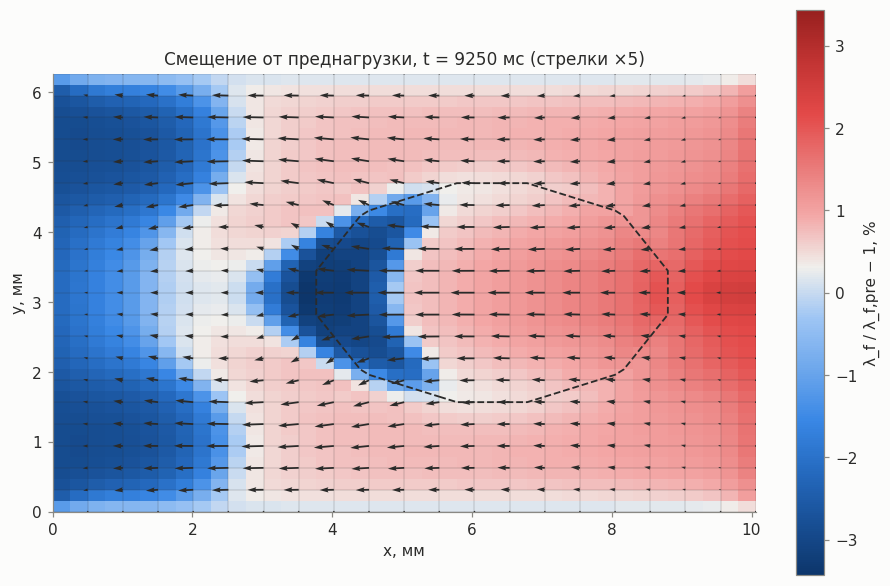

In [5]:
_, _, ux_k, uy_k = geometry(peak)
dux, duy = ux_k - ux_pre, uy_k - uy_pre
step = max(1, (X0.shape[1] - 1) // 16)
sl = (slice(0, None, step), slice(0, None, step))
mag = np.hypot(dux, duy)

fig, ax = plt.subplots(figsize=(8, 6.5), constrained_layout=True)
pc = draw(ax, Xp, Yp, s_peak, style.div, s_norm, region_n,
          f"Смещение от преднагрузки, t = {peak.t_ms:g} мс (стрелки ×{AMPLIFY:g})")
ax.quiver(Xp[sl], Yp[sl], AMPLIFY * dux[sl], AMPLIFY * duy[sl], angles="xy",
          scale_units="xy", scale=1, width=0.0025, color=style.ink)
fig.colorbar(pc, ax=ax, shrink=0.8, label="λ_f / λ_f,pre − 1, %")
save(fig, "displacement_peak")
print(f"|u − u_pre| на пике: макс. {mag.max() * 1000:.1f} мкм, средн. {mag.mean() * 1000:.1f} мкм")

## 4. Установившийся удар: раскадровка

Все снимки последнего удара на преднагруженной сетке со смещениями ×`AMPLIFY`; шкала цвета
общая для всех кадров.

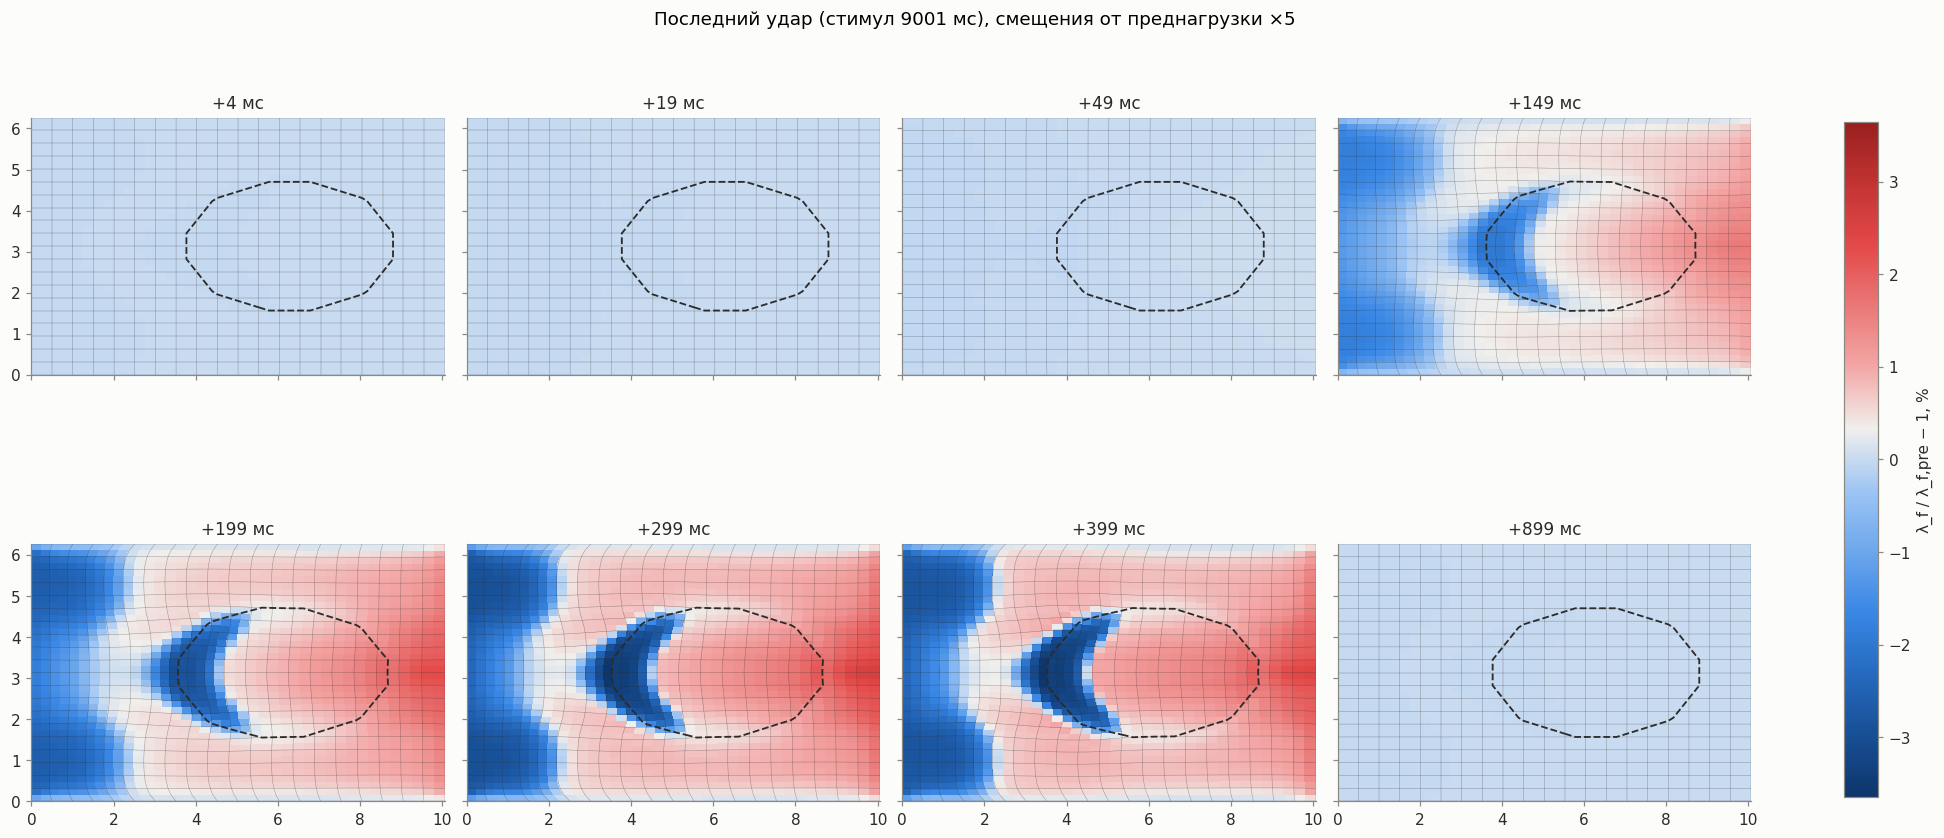

In [6]:
MAX_PANELS = 8
pick = np.unique(np.linspace(0, len(beat) - 1, min(len(beat), MAX_PANELS)).round().astype(int))
frames = [beat[i] for i in pick]
S = [strain(sn) for sn in frames]
span_b = max(max(np.abs(s).max() for s in S), 1e-6)
norm_b = TwoSlopeNorm(0.0, -span_b, span_b)

ncol = min(len(frames), 4)
nrow = int(np.ceil(len(frames) / ncol))
fig, axs = plt.subplots(nrow, ncol, figsize=(4.4 * ncol, 4.0 * nrow), constrained_layout=True,
                        squeeze=False, sharex=True, sharey=True)
for ax, sn, s in zip(axs.flat, frames, S):
    X, Y = deformed(sn, AMPLIFY)
    pc = draw(ax, X, Y, s, style.div, norm_b, region_on_nodes(sn),
              f"+{sn.t_ms - last_stim:g} мс")
    ax.set_xlabel("")
    ax.set_ylabel("")
for ax in list(axs.flat)[len(frames):]:
    ax.axis("off")
fig.colorbar(pc, ax=axs, shrink=0.8, label="λ_f / λ_f,pre − 1, %")
fig.suptitle(f"Последний удар (стимул {last_stim:g} мс), смещения от преднагрузки ×{AMPLIFY:g}")
save(fig, "beat_sequence")

## 5. Выход на стационар и ход удара по регионам

Слева — по каждому удару из `series.csv`: наименьшее λ_f в ткани (самое сильное укорочение)
и пик действующего активного напряжения; если последние удары совпадают — ритм установился.
Справа — среднее растяжение волокна относительно преднагрузки по регионам в последнем ударе
(по снимкам). В ишемическом регионе при сокращении окружающей ткани волокно может
**удлиняться** — пассивное выбухание слабой зоны.

изменение за последние удары: min λ_f 1.56e-03, пик T_act 0.03 кПа


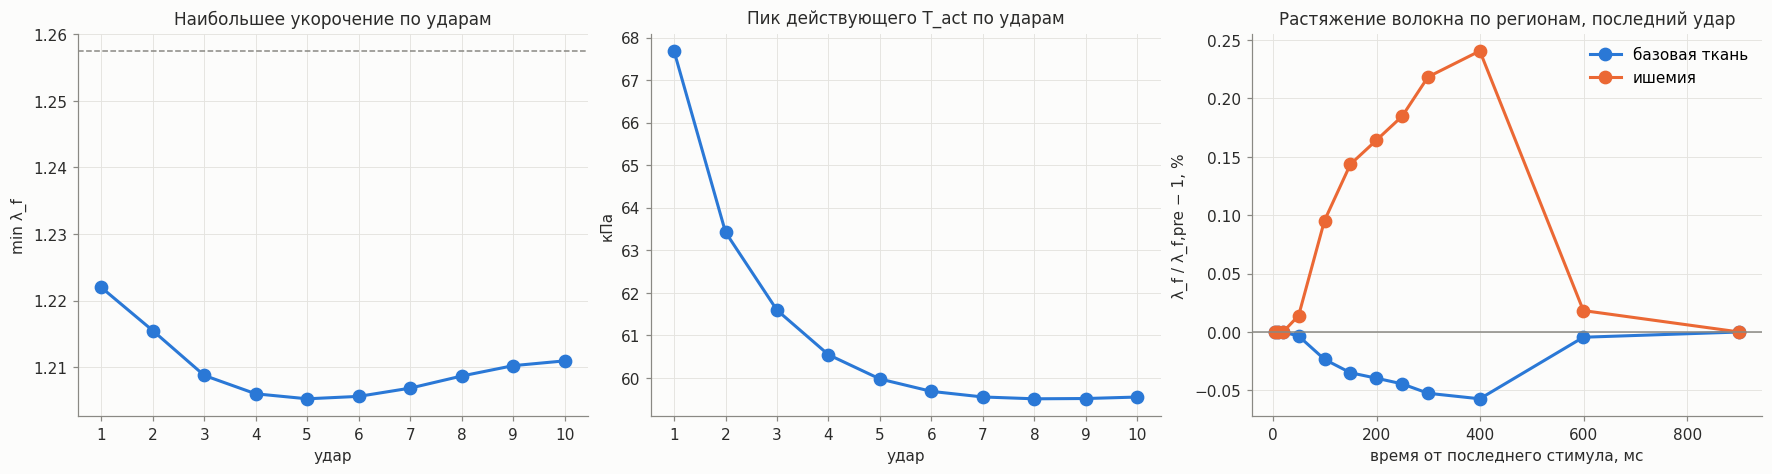

In [7]:
s = run.series()
t = s["t_ms"]
edges = list(STIM) + [T_END + 1e-9]
per_beat = []
for k in range(len(STIM)):
    m = (t >= edges[k]) & (t < edges[k + 1])
    if m.any():
        per_beat.append((k + 1, np.nanmin(s["lambda_f_min"][m]), np.nanmax(s["t_act_actual_max"][m])))
per_beat = np.array(per_beat)

names = {0: "базовая ткань", **{i + 1: r.get("name") or f"регион {i + 1}"
                                for i, r in enumerate(run.config.get("regions", []))}}
regs = [int(r) for r in np.unique(reg_cells)]
curves = {r: [] for r in regs}
for sn in beat:
    st = strain(sn)
    rc = sn.grid("m_region")
    for r in regs:
        curves[r].append(st[rc == r].mean())
tb = [sn.t_ms - last_stim for sn in beat]

fig, axs = plt.subplots(1, 3, figsize=(16, 4.2), constrained_layout=True)
axs[0].plot(per_beat[:, 0], per_beat[:, 1], marker="o")
axs[0].axhline(LAMBDA_PRE, color=style.muted, lw=1, ls="--")
axs[0].set_xlabel("удар")
axs[0].set_ylabel("min λ_f")
axs[0].set_title("Наибольшее укорочение по ударам")
axs[1].plot(per_beat[:, 0], per_beat[:, 2], marker="o")
axs[1].set_xlabel("удар")
axs[1].set_ylabel("кПа")
axs[1].set_title("Пик действующего T_act по ударам")
for r, c in zip(regs, style.series):
    axs[2].plot(tb, curves[r], marker="o", color=c, label=names.get(r, r))
axs[2].axhline(0, color=style.muted, lw=1)
axs[2].set_xlabel("время от последнего стимула, мс")
axs[2].set_ylabel("λ_f / λ_f,pre − 1, %")
axs[2].set_title("Растяжение волокна по регионам, последний удар")
axs[2].legend()
for ax in axs[:2]:
    ax.set_xticks(per_beat[:, 0])
save(fig, "steady_state")

if len(per_beat) > 1:
    d = np.abs(np.diff(per_beat[-3:, 1:], axis=0)).max(axis=0) if len(per_beat) > 2 else np.abs(per_beat[-1, 1:] - per_beat[-2, 1:])
    print(f"изменение за последние удары: min λ_f {d[0]:.2e}, пик T_act {d[1]:.2f} кПа")

## 6. Анимация последнего удара

Все снимки удара, смещения от преднагрузки ×`AMPLIFY`, пунктир — граница преднагруженной
области (чтобы было видно, куда сдвигаются края).

In [8]:
from IPython.display import HTML
from matplotlib import animation

if len(beat) > 1:
    SA = [strain(sn) for sn in beat]
    span_a = max(max(np.abs(x).max() for x in SA), 1e-6)
    norm_a = TwoSlopeNorm(0.0, -span_a, span_a)
    fig, ax = plt.subplots(figsize=(7, 5.5), constrained_layout=True)
    pad = 0.05 * (Xp.max() - Xp.min())
    ax.set_xlim(Xp.min() - pad, Xp.max() + pad)
    ax.set_ylim(Yp.min() - pad, Yp.max() + pad)
    ax.plot(np.r_[Xp[0], Xp[:, -1], Xp[-1, ::-1], Xp[::-1, 0]],
            np.r_[Yp[0], Yp[:, -1], Yp[-1, ::-1], Yp[::-1, 0]], color=style.muted, lw=1, ls=":")
    X, Y = deformed(beat[0], AMPLIFY)
    pc = ax.pcolormesh(X, Y, SA[0], cmap=style.div, norm=norm_a, shading="flat")
    ax.set_aspect("equal")
    ax.grid(False)
    fig.colorbar(pc, ax=ax, shrink=0.8, label="λ_f / λ_f,pre − 1, %")
    title = ax.set_title("")

    def frame(i):
        global pc
        pc.remove()
        X, Y = deformed(beat[i], AMPLIFY)
        pc = ax.pcolormesh(X, Y, SA[i], cmap=style.div, norm=norm_a, shading="flat")
        title.set_text(f"+{beat[i].t_ms - last_stim:g} мс после стимула, смещения ×{AMPLIFY:g}")
        return pc, title

    anim = animation.FuncAnimation(fig, frame, frames=len(beat), interval=300)
    plt.close(fig)
    if SAVE:
        anim.save(FIG_DIR / "beat_animation.gif", writer="pillow", fps=3, dpi=90)
    display(HTML(anim.to_jshtml()))

## 7. Стадии ишемии: пик последнего удара

Каждая точка серии — на своей преднагруженной сетке, смещения ×`AMPLIFY`, общая шкала.
Внизу — среднее растяжение волокна в регионе и в базовой ткани на пике.

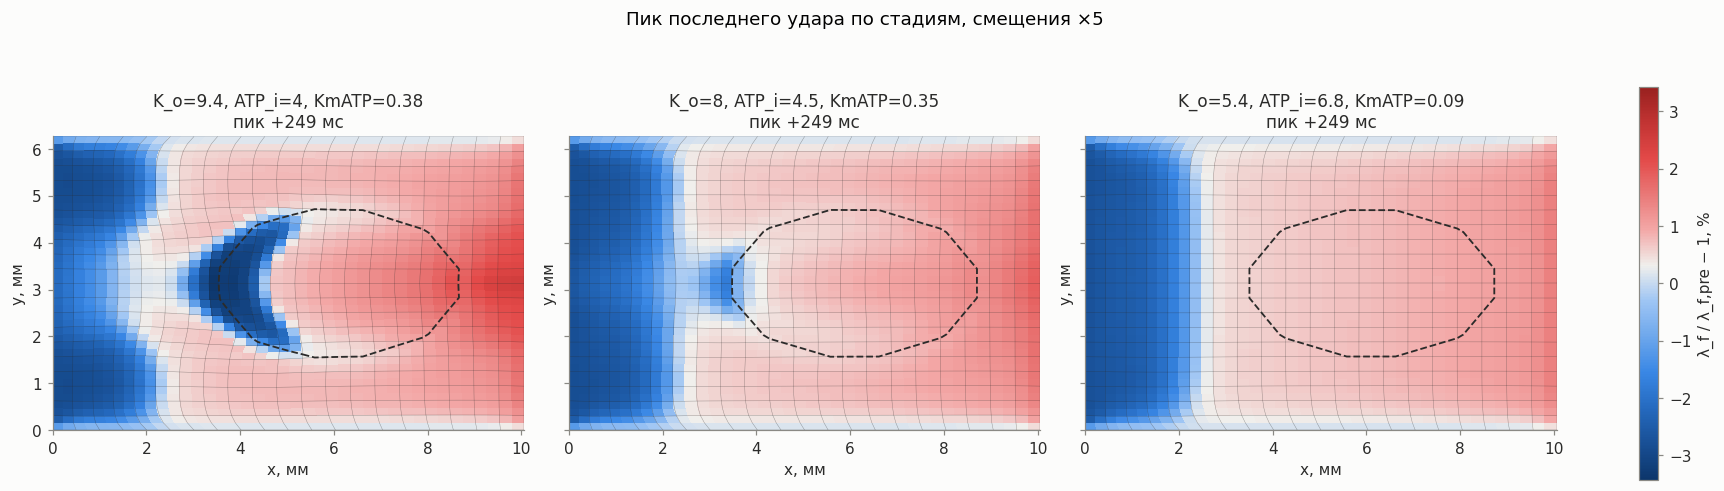

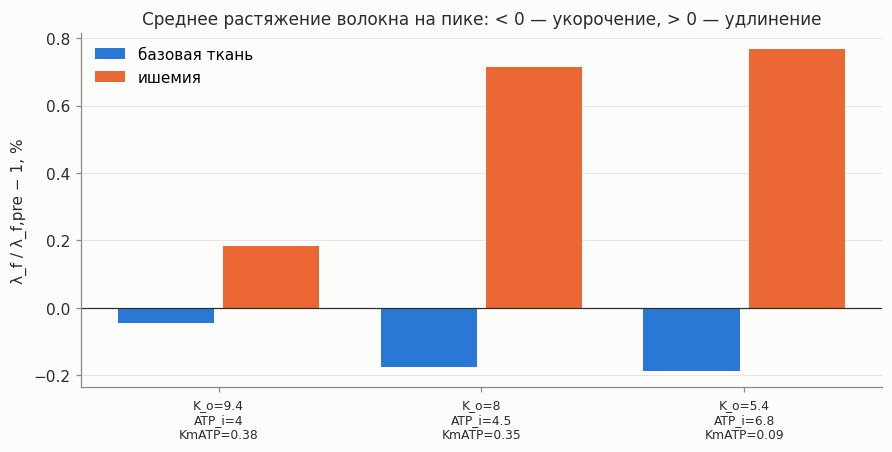

In [9]:
def peak_state(r):
    sn_all = list(r.snapshots())
    p0 = sn_all[0]
    stims = sorted(r.config["stimulus"]["times_ms"])
    t_end = r.manifest["schedule"]["t_end_ms"]
    ls = max(t for t in stims if t < t_end)
    bt = [q for q in sn_all if q.t_ms >= ls]
    pk = max(bt, key=lambda q: q["m_t_act"].mean())
    _, _, uxp, uyp = geometry(p0)
    x0, y0, ux, uy = geometry(pk)
    st = 100.0 * (pk.grid("m_lambda_f") / p0.grid("m_lambda_f") - 1.0)
    X = x0 + uxp + AMPLIFY * (ux - uxp)
    Y = y0 + uyp + AMPLIFY * (uy - uyp)
    return X, Y, st, region_on_nodes(pk), pk.grid("m_region"), pk.t_ms - ls


if (SWEEP_DIR / "sweep.json").exists():
    sweep = open_sweep(SWEEP_DIR)
    items = []
    for p, r in sweep.runs():
        lab = ", ".join(f"{k.split('.')[-1].removeprefix('cell:')}={v:g}" for k, v in p["overrides"].items())
        items.append((lab, *peak_state(r)))
    if items:
        span_s = max(np.abs(it[3]).max() for it in items)
        norm_s = TwoSlopeNorm(0.0, -span_s, span_s)
        fig, axs = plt.subplots(1, len(items), figsize=(5.2 * len(items), 4.8),
                                constrained_layout=True, squeeze=False, sharex=True, sharey=True)
        for ax, (lab, X, Y, st, rn, rc, dt) in zip(axs[0], items):
            pc = draw(ax, X, Y, st, style.div, norm_s, rn, f"{lab}\nпик +{dt:g} мс")
        fig.colorbar(pc, ax=axs, shrink=0.8, label="λ_f / λ_f,pre − 1, %")
        fig.suptitle(f"Пик последнего удара по стадиям, смещения ×{AMPLIFY:g}")
        if SAVE:
            (SWEEP_DIR / "figures").mkdir(exist_ok=True)
            fig.savefig(SWEEP_DIR / "figures" / "deformation_peak_by_stage.png", dpi=160,
                        bbox_inches="tight")

        # средние по регионам: столбцы — стадии, цвет — регион
        regs_s = sorted({int(v) for it in items for v in np.unique(it[5])})
        w = 0.8 / len(regs_s)
        fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
        for j, (r, c) in enumerate(zip(regs_s, style.series)):
            vals = [it[3][it[5] == r].mean() if (it[5] == r).any() else np.nan for it in items]
            xs = np.arange(len(items)) + (j - (len(regs_s) - 1) / 2) * w
            ax.bar(xs, vals, width=w * 0.92, color=c, label=names.get(r, f"регион {r}"))
        ax.axhline(0, color=style.ink, lw=0.8)
        ax.set_xticks(range(len(items)), [it[0].replace(", ", "\n") for it in items], fontsize=8)
        ax.set_ylabel("λ_f / λ_f,pre − 1, %")
        ax.set_title("Среднее растяжение волокна на пике: < 0 — укорочение, > 0 — удлинение")
        ax.grid(axis="x", visible=False)
        ax.legend()
        if SAVE:
            fig.savefig(SWEEP_DIR / "figures" / "strain_by_region_stage.png", dpi=160,
                        bbox_inches="tight")
    else:
        print("в серии нет завершённых точек")
else:
    print(f"серии в {SWEEP_DIR.relative_to(ROOT)} нет")